# Import Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import dates as md
import time
import re, fileinput, sys, pathlib, os
from itertools import cycle
import numpy as np

In [2]:
def parsefile(file):
    throughput_pattern = re.compile(r'\[OVERALL\], Throughput\(ops/sec\), (\d+.?\d*)')
    read_num_pattern = re.compile(r'\[READ\], Total Operations, (\d+)')
    read_ok_pattern = re.compile(r'\[READ\], Return=OK, (\d+)')
    read_pattern = re.compile(r'\[READ\], ([A-Za-z]+|p\d+\.?\d*), (\d+)')
    update_pattern = re.compile(r'\[UPDATE\], ([A-Za-z]+|p\d+\.?\d*), (\d+)')
    update_num_pattern = re.compile(r'\[UPDATE\], Total Operations, (\d+)')
    update_ok_pattern = re.compile(r'\[UPDATE\], Return=OK, (\d+)')
    runtimep = re.compile(r'\[OVERALL\], RunTime\(ms\), (\d+)')
    throughput = 'not_found'
    read_num = 'not_found'
    read_ok = 'not_found'
    read = {}
    update_num = 'not_found'
    update_ok = 'not_found'
    update = {}

    result = {}
    
    with open(file) as f:
        for line in f:
            m = runtimep.search(line)
            if m:
                result = result | {'runtime(ms)': m.group(1)}
            m = throughput_pattern.search(line)
            if m:
                throughput = m.group(1)
            m = read_num_pattern.search(line)
            if m:
                read_num = m.group(1)
            m = read_ok_pattern.search(line)
            if m:
                read_ok = m.group(1)
            m = read_pattern.search(line)
            if m:
                label = f'read_{m.group(1).lower()}(us)'
                read = read | {label: m.group(2)}
            m = update_num_pattern.search(line)
            if m:
                update_num = m.group(1)
            m = update_ok_pattern.search(line)
            if m:
                update_ok = m.group(1)
            m = update_pattern.search(line)
            if m:
                label = f'update_{m.group(1).lower()}(us)'
                update = update | {label: m.group(2)}
    return result | {'throughput(ops/s)': [throughput], 'read_num': [read_num], 'read_ok': [read_ok], 'update_num': [update_num], 'update_ok': [update_ok]} | read | update

In [3]:
df = pd.DataFrame()
workloadp = re.compile(r'workload[a-z]|writeonly|readonly')
nodesp = re.compile(r'(\d+)nodes')
threadsp = re.compile(r'(\d+)threads')
targetp = re.compile(r'([0-9a-z]+)target')
operationsp = re.compile(r'(\d+)operations')
recordsp = re.compile(r'(\d+)records')
timeoutp = re.compile(r'(\d+)timeout')
batchsizep = re.compile(r'(\d+)batchsize')
kill_leaderp = re.compile(r'(\d+)kill_leader')
timep = re.compile(r'\d+-\d+-\d+-\d+:\d+:\d+')
geo_replp = re.compile(r'geo-repl')
single_conp = re.compile(r'single-con')
historyp = re.compile(r'history([A-Za-z]+\d*)')
commitreadsp = re.compile(r'commitreads([A-Za-z]+)')
twconnp = re.compile(r'twoWayConnections')
smallrepp = re.compile(r'smallReplies')
futurep = re.compile(r'future')
atomicp = re.compile(r'atomic-refs')
testp = re.compile(r'simple-test')
for kind in ['pb', 'etcd']:
    for fileObj in os.scandir("../results/raw/"+kind):
        file = fileObj.name
        workload = workloadp.search(file).group()
        nodes = nodesp.search(file).group(1)
        threads = threadsp.search(file).group(1)
        target = targetp.search(file).group(1)
        time = timep.search(file).group(0)
        m = commitreadsp.search(file)
        if m:
            commitreads = m.group(1).lower()
        else:
            commitreads = 'undefined'
        m = operationsp.search(file)
        if m:
            operations = m.group(1)
        else:
            operations = 'undefined'
        m = recordsp.search(file)
        if m:
            records = m.group(1)
        else:
            records = 'undefined'
        m = timeoutp.search(file)
        if m:
            timeout = m.group(1)
        else:
            timeout = 'undefined'
        m = batchsizep.search(file)
        if m:
            batchsize = m.group(1)
        else:
            batchsize = 'undefined'
        m = kill_leaderp.search(file)
        if m:
            kill_leader = m.group(1)
        else:
            kill_leader = 'undefined'
        m = geo_replp.search(file)
        if m:
            geo_repl = True
        else:
            geo_repl = False
        m = single_conp.search(file)
        if m:
            single_con = True
        else:
            single_con = False
        m = historyp.search(file)
        if m:
            history = m.group(1).lower()
        else:
            history = 'undefined'
        m = twconnp.search(file)
        if m:
            twconn = True
        else:
            twconn = 'undefined'
        m = smallrepp.search(file)
        if m:
            smallrep = True
        else:
            smallrep = 'undefined'
        m = futurep.search(file)
        if m:
            future = True
        else:
            future = 'undefined'
        m = atomicp.search(file)
        if m:
            atomic = True
        else:
            atomic = 'undefined'
        m = testp.search(file)
        if m:
            test = True
        else:
            test = 'undefined'
    
        header_data = {'system': [kind], 'small_replies': [smallrep], 'simple_test': [test], 'future': [future], 'atomic_refs': [atomic], 'single_con': [single_con], 'tw_conn': [twconn], 'geo_repl': [geo_repl], 'time': [time], 'workload': [workload], 'nodes': [nodes], 'threads': [threads], 'target': [target], 'operations': [operations], 'records': [records], 'timeout': [timeout], 'batchsize': [batchsize], 'kill_leader': [kill_leader], 'history': [history], 'filename': [file], 'commit_reads': [commitreads]}
        in_file_data = parsefile(fileObj.path)
        new_row = pd.DataFrame(header_data | in_file_data)
        df = pd.concat([df,new_row])
    

In [4]:
# clean up df and change datatypes
df = df[df['throughput(ops/s)'] != 'not_found']
df['time'] = pd.to_datetime(df['time'])
df = df.astype({'nodes': 'int32', 'threads': 'int32', 'throughput(ops/s)': 'float64', 'update_p90(us)': 'Int64', 'update_p99(us)': 'Int64', 'update_average(us)': 'Int64','runtime(ms)': 'int64', 'timeout': 'int64'})
df['update_p99(ms)'] = df['update_p99(us)'] / 1000
df['update_p90(ms)'] = df['update_p90(us)'] / 1000
df['update_average(ms)'] = df['update_average(us)'] / 1000
df['runtime(s)'] = df['runtime(ms)'] / 1000
df = df.round({"runtime(s)": 0})
df['runtime(s)'] = df['runtime(s)'].astype(int)
#df['read_p99(ms)'] = df['read_p99(us)'] / 1000
df = df.reset_index()
df.drop('index', axis=1)

,system,small_replies,simple_test,future,atomic_refs,single_con,tw_conn,geo_repl,time,workload,...,update_p50(us),update_p90(us),update_p95(us),update_p99(us),update_p99.9(us),update_p99.99(us),update_p99(ms),update_p90(ms),update_average(ms),runtime(s)
0,pb,undefined,undefined,undefined,undefined,False,undefined,False,2026-07-23 15:04:42,writeonly,...,1207,1858,1990,2846,7851,92583,2.846,1.858,1.338,73
1,pb,undefined,undefined,undefined,undefined,False,undefined,False,2026-07-23 15:39:29,writeonly,...,687,1042,1222,2160,4735,21830,2.16,1.042,0.788,46
2,pb,undefined,undefined,undefined,undefined,False,undefined,False,2026-07-23 15:41:15,writeonly,...,698,1087,1166,1833,12758,48238,1.833,1.087,0.851,28
3,pb,undefined,undefined,undefined,undefined,False,undefined,False,2026-07-23 15:43:03,writeonly,...,891,1450,1579,2747,16590,83200,2.747,1.45,1.124,24
4,pb,undefined,undefined,undefined,undefined,False,undefined,False,2026-07-23 15:44:53,writeonly,...,5658,10244,10860,19218,57787,102483,19.218,10.244,7.143,24
5,pb,undefined,undefined,undefined,undefined,False,undefined,False,2026-07-23 16:24:32,writeonly,...,438,966,1081,1615,4025,27417,1.615,0.966,0.573,35
6,pb,undefined,undefined,undefined,undefined,False,undefined,False,2026-07-23 16:26:17,writeonly,...,578,950,1055,1742,12987,43288,1.742,0.95,0.755,24
7,pb,undefined,undefined,undefined,undefined,False,undefined,False,2026-07-23 16:28:08,writeonly,...,859,1477,1579,2604,14890,49401,2.604,1.477,1.107,25
8,pb,undefined,undefined,undefined,undefined,False,undefined,False,2026-07-23 16:29:54,writeonly,...,5638,9334,10103,20408,48786,434451,20.408,9.334,7.26,24
9,pb,undefined,undefined,undefined,undefined,False,undefined,False,2026-07-23 16:31:39,writeonly,...,432,942,1028,1788,4104,26940,1.788,0.942,0.569,34


# Leader Failure

## helper functions

In [5]:
# split file
def file_to_df(file):
    pattern = re.compile(r'(Hello from .*)|(Raw data measurement: .*)|(\[.*)|ensuring|failed to write sth')
    markerline = re.compile(r'([A-Z]*\-?[A-Z]*)( latency raw data.*)')
    outdir = pathlib.Path('output')
    outdir.mkdir(parents=True, exist_ok=True)
    out = None
    
    
    with open(file) as f:
        for line in f:
            m = markerline.search(line)
            if m:               # marker line → new file
                if out: out.close()
                out = (outdir / f'{m.group(1)}.txt').open('w')
            if out and not pattern.search(line):                              # drop lines until 1st match
                out.write(line)
    if out: out.close()

    return pd.read_csv("output/UPDATE.txt", delimiter=",", skipinitialspace=True, dtype={'latency(us)': 'long'})

In [6]:
def normalize_df(dataframe):
    dataframe['timestamp(ms)'] = pd.to_datetime(dataframe['timestamp(ms)'], unit='ms')
    start = dataframe['timestamp(ms)'].min()
    dataframe['t_sec'] = (dataframe['timestamp(ms)'] - start).dt.total_seconds()
    dataframe['ts_norm'] = (dataframe['timestamp(ms)'] - start)
    return dataframe

def print_leader_failure(xlim=None, xticks=None, xsize=None, ysize=None):
    ax = None
    from itertools import cycle
    # solid, dotted, dashed, long dash with offsets, dashdotted, dashdotdotted
    lines = ['solid',"dotted"]
    linestylecycler = cycle(lines)

    for system in ['pb', 'etcd']:
        prop_cycle = plt.rcParams['axes.prop_cycle']
        mptcolors = prop_cycle.by_key()['color']
        colorcycler = cycle(['blue', 'orange', 'green', 'purple'])
        linestyle = next(linestylecycler)
        for threads in [1, 2, 3, 20]:
            relevant_data = df[(df['kill_leader'] == '10') & (df['timeout'] == 5000) & (df['threads'] == threads) & (df['system'] == system) & (df['workload'] == 'writeonly') & (df['time'] >= '2026-03-13')]
            # last 3 entries
            relevant_data = relevant_data.sort_values('time').groupby(['system', 'threads', 'timeout', 'kill_leader']).tail(3)
            dataframes = [ normalize_df(file_to_df(f"../results/raw/{system}/{row.filename}")) for row in relevant_data.itertuples()]
            print(f"found {len(dataframes)} dataframes for {system}")
            if len(dataframes) > 0:
                aggregated = pd.concat(dataframes, ignore_index=True)
                groups = aggregated.groupby(pd.Grouper(key='ts_norm', freq='1s', closed='right'))
                tp_groups = groups.size().to_frame(name="ops/s")
                if system == 'pb':
                    tp_groups['ops/s'] = (tp_groups['ops/s'] / len(dataframes))
                else:
                    tp_groups['ops/s'] = (tp_groups['ops/s'] / len(dataframes))
                tp_groups = tp_groups.reset_index()
                tp_groups['ts_norm_s'] = tp_groups['ts_norm'].map(lambda x: x.value / 1000000000)
                tp_groups['ts_norm_s'] = tp_groups['ts_norm_s']
                if system == 'pb':
                    systemlabel = 'PRDT'
                else:
                    systemlabel = system
                label = f'{systemlabel} {threads} clients'
                if ax:
                    tp_groups.plot(x='ts_norm_s', y='ops/s', label=label, linestyle=linestyle, color=next(colorcycler), ax = ax)
                else:
                    ax = tp_groups.plot(x='ts_norm_s', y='ops/s', label=label, linestyle=linestyle, color=next(colorcycler), ax = ax)
    if xlim:
        plt.xlim(xlim)
    if xticks is not None:
        plt.xticks(xticks)
   # plt.axvline(x=30, color='red', linestyle='--')
    if xsize is not None and ysize is not None:
        ax.figure.set_size_inches(xsize, ysize)
    plt.legend(loc='right')
    plt.xlabel('time (s)')
    plt.ylabel('throughput(ops/s)')
    plt.savefig(f'leader_failure.pdf', bbox_inches='tight')


## export plots

found 3 dataframes for pb
found 3 dataframes for pb
found 3 dataframes for pb
found 3 dataframes for pb
found 3 dataframes for etcd
found 2 dataframes for etcd
found 2 dataframes for etcd
found 2 dataframes for etcd


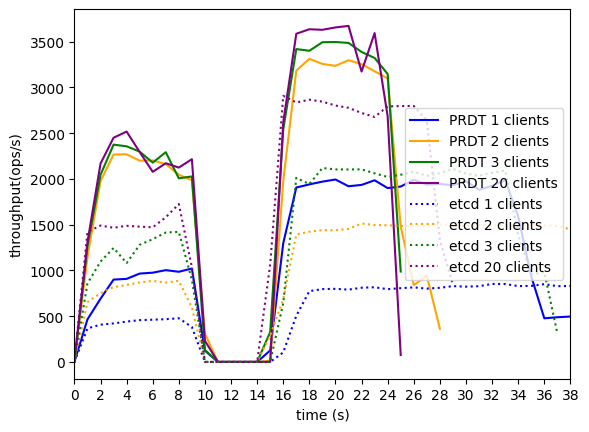

In [7]:
print_leader_failure(xlim=[0,38], xticks=np.arange(0, 38 + 2, 2))
#print_leader_failure(xlim=[0,38], xticks=np.arange(0, 38 + 2, 2), xsize=10.0, ysize=4.0)